# Benchmarking ML — Prediccion de Sobrecosto en Contratos Publicos

**Dataset:** `docs/contratos_features.csv` (351 contratos, 219 features)  
**Origen:** `docs/matriz_clean.csv` → `estudio_data/features.py`  
**Variable objetivo:** `sobrecosto`  
**Modelos:** Ridge, Lasso, ElasticNet, KNN, DecisionTree, RandomForest, GradientBoosting, XGBoost, SVR, MLP  
**Validacion:** Nested CV (5 outer / 5 inner), RandomizedSearchCV (100 iter), HalvingSearchCV, Optuna Bayesiana  
**XAI:** SHAP, permutation importance, residual analysis

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import time
import re
import joblib
from pathlib import Path

# 🔥 ¡IMPORTANTE! HABILITAR HALVING ANTES DE IMPORTAR model_selection
from sklearn.experimental import enable_halving_search_cv

from scipy.stats import randint, uniform, loguniform, ttest_rel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    learning_curve,
    HalvingRandomSearchCV  # ← Ahora está habilitado
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

RESULTADOS = Path('resultados')
RESULTADOS.mkdir(exist_ok=True)
print('Listo')

Listo


---
## 1. Carga de Features Persistentes

In [20]:
df = pd.read_csv('../docs/contratos_features.csv', encoding='utf-8-sig')
print(f'Contratos: {len(df)} | Features: {df.shape[1]}')
df.head(5)

Contratos: 351 | Features: 219


,id_contrato,valor_inicial,sobrecosto,fuente,n_riesgos,prob_promedio,prob_std,prob_min,prob_max,prob_rango,...,tfidf_seguridad,tfidf_seleccion,tfidf_senalizacion,tfidf_servicios,tfidf_tasas,tfidf_tecnicas,tfidf_terceros,tfidf_trabajo,tfidf_variacion,tfidf_variaciones
0,C-001,16147899764,28.56,tolima,12,2.083333,0.276385,2.0,3.0,1.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.21591,0.000000,0.000000,0.000000
1,C-002,105418335674,4.80,amva,19,1.736842,0.848659,1.0,3.0,2.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.164614,0.00000,0.000000,0.094448,0.000000
2,C-003,46952850500,53.10,rionegro,8,2.375000,0.695971,2.0,4.0,2.0,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
3,C-004,43371238623,26.33,cucuta,10,1.300000,0.458258,1.0,2.0,1.0,...,0.132919,0.0,0.0,0.000000,0.000000,0.125791,0.00000,0.000000,0.000000,0.000000
4,C-005,40110983232,37.28,cali,32,2.187500,0.582961,1.0,3.0,2.0,...,0.000000,0.0,0.0,0.329863,0.069068,0.000000,0.10842,0.127394,0.000000,0.137521


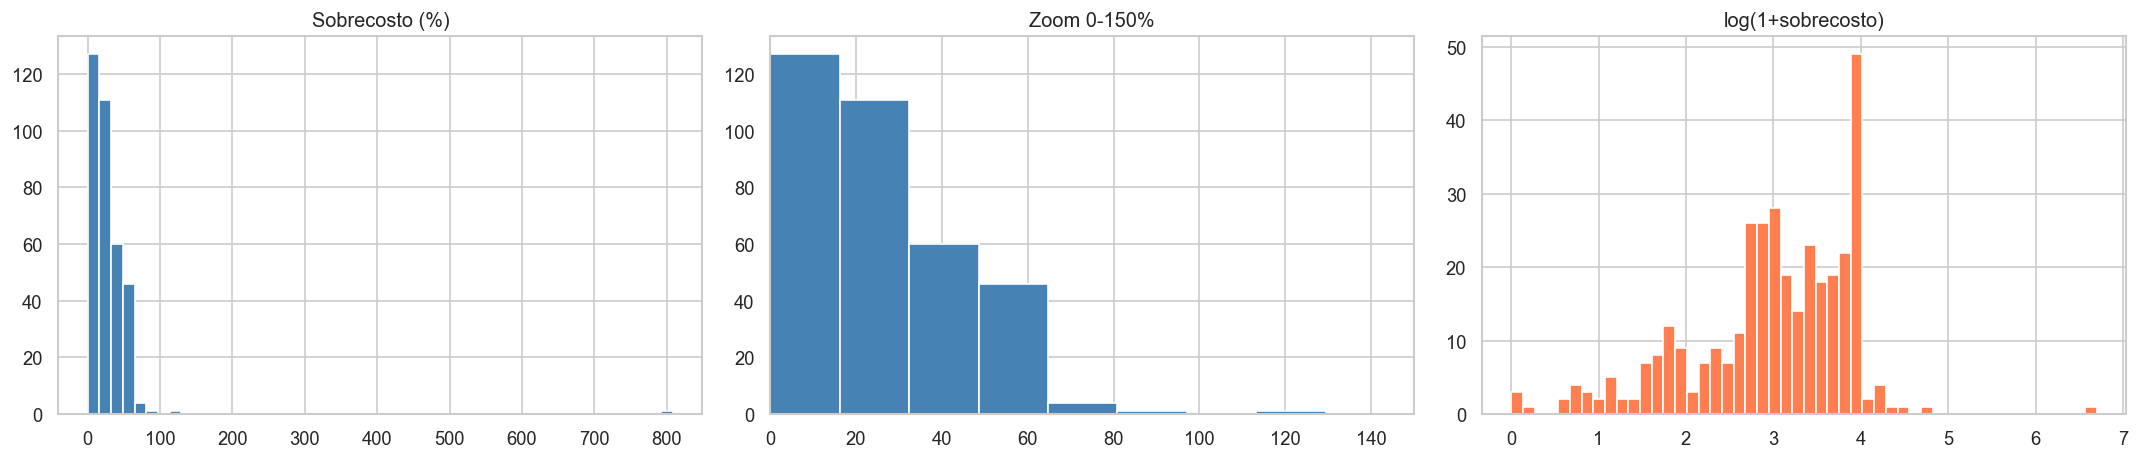

Media: 27.5%  |  >200%: 1 contratos


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df['sobrecosto'], bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Sobrecosto (%)')
axes[1].hist(df['sobrecosto'], bins=50, edgecolor='white', color='steelblue')
axes[1].set_xlim(0, 150); axes[1].set_title('Zoom 0-150%')
axes[2].hist(np.log1p(df['sobrecosto']), bins=50, edgecolor='white', color='coral')
axes[2].set_title('log(1+sobrecosto)')
plt.tight_layout(); plt.savefig(RESULTADOS / 'target_dist.png', dpi=100, bbox_inches='tight'); plt.show()
media = df['sobrecosto'].mean()
outliers_200 = (df['sobrecosto'] > 200).sum()
print(f'Media: {media:.1f}%  |  >200%: {outliers_200} contratos')

---
## 2. Preparacion Train/Test

In [22]:
target = 'sobrecosto'
excluir = ['id_contrato', 'sobrecosto', 'fuente', 'valor_inicial']
feature_cols = [c for c in df.columns if c not in excluir]
X = df[feature_cols].copy(); y = df[target].copy()
X = X.fillna(X.median())
outliers_mask = y > 200
print(f'Outliers >200% eliminados: {outliers_mask.sum()}')
X_sin = X[~outliers_mask]; y_sin = y[~outliers_mask]
X_train, X_test, y_train, y_test = train_test_split(X_sin, y_sin, test_size=0.3, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_cols)}')

Outliers >200% eliminados: 1
Train: 245 | Test: 105 | Features: 215


---
## 3. Benchmarking — 10 Modelos con Nested CV (100 iter)

In [23]:
from sklearn.linear_model import Ridge, Lasso, ElasticNetfrom sklearn.neighbors import KNeighborsRegressorfrom sklearn.tree import DecisionTreeRegressorfrom sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressorfrom sklearn.svm import SVRfrom sklearn.neural_network import MLPRegressorfrom xgboost import XGBRegressordef rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))def evaluar(y_true, y_pred):    return {'RMSE': rmse(y_true, y_pred), 'MAE': mean_absolute_error(y_true, y_pred), 'R2': r2_score(y_true, y_pred)}MODELOS = {    'Ridge': {'m': Ridge(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3)}},    'Lasso': {'m': Lasso(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3)}},    'ElasticNet': {'m': ElasticNet(random_state=42), 'p': {'m__alpha': loguniform(1e-3, 1e3), 'm__l1_ratio': uniform(0.1, 0.8)}},    'KNN': {'m': KNeighborsRegressor(), 'p': {'m__n_neighbors': randint(3, 30), 'm__weights': ['uniform', 'distance'], 'm__p': [1, 2]}},    'DecisionTree': {'m': DecisionTreeRegressor(random_state=42), 'p': {'m__max_depth': randint(3, 25), 'm__min_samples_split': randint(2, 25), 'm__min_samples_leaf': randint(1, 15), 'm__max_features': ['sqrt', 'log2', None]}},    'RandomForest': {'m': RandomForestRegressor(random_state=42, n_jobs=-1), 'p': {'m__n_estimators': randint(150, 600), 'm__max_depth': randint(5, 30), 'm__min_samples_split': randint(2, 20), 'm__min_samples_leaf': randint(1, 10), 'm__max_features': ['sqrt', 'log2', None]}},    'GradientBoosting': {'m': GradientBoostingRegressor(random_state=42), 'p': {'m__n_estimators': randint(100, 500), 'm__max_depth': randint(3, 10), 'm__learning_rate': uniform(0.01, 0.3), 'm__subsample': uniform(0.7, 0.3)}},    'XGBoost': {'m': XGBRegressor(random_state=42, verbosity=0, n_jobs=-1, n_estimators=2000, early_stopping_rounds=50), 'p': {'m__max_depth': randint(3, 12), 'm__learning_rate': uniform(0.01, 0.3), 'm__subsample': uniform(0.6, 0.4), 'm__colsample_bytree': uniform(0.6, 0.4), 'm__reg_alpha': loguniform(1e-3, 10), 'm__reg_lambda': loguniform(1e-3, 10), 'm__gamma': uniform(0, 5), 'm__min_child_weight': randint(1, 10)}},    'SVR': {'m': SVR(), 'p': {'m__kernel': ['rbf', 'poly', 'sigmoid'], 'm__C': loguniform(0.01, 100), 'm__gamma': loguniform(0.001, 10), 'm__epsilon': uniform(0.01, 0.5)}},    'MLP': {'m': MLPRegressor(random_state=42, max_iter=500, early_stopping=True), 'p': {'m__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)], 'm__activation': ['relu', 'tanh'], 'm__alpha': loguniform(1e-4, 1), 'm__learning_rate_init': loguniform(1e-4, 0.01)}},}

In [24]:
def nested_cv(X, y, md, nombre, n_outer=5, n_inner=5, n_iter=100):    outer_cv = KFold(n_splits=n_outer, shuffle=True, random_state=42)    resultados_outer, tiempos, mejores_params = [], [], []    for fold, (tr_idx, val_idx) in enumerate(outer_cv.split(X)):        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]        pipe = Pipeline([('scaler', StandardScaler()), ('m', md['m'])])        inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=42)        search = RandomizedSearchCV(pipe, md['p'], n_iter=n_iter, cv=inner_cv,            scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)        t0 = time.time(); search.fit(X_tr, y_tr)        tiempos.append(time.time() - t0); mejores_params.append(search.best_params_)        resultados_outer.append(evaluar(y_val.values, search.predict(X_val)))    df_res = pd.DataFrame(resultados_outer)    return {'modelo': nombre, 'RMSE_mean': df_res['RMSE'].mean(), 'RMSE_std': df_res['RMSE'].std(),            'MAE_mean': df_res['MAE'].mean(), 'MAE_std': df_res['MAE'].std(),            'R2_mean': df_res['R2'].mean(), 'R2_std': df_res['R2'].std(),            'tiempo_mean': np.mean(tiempos), 'best_params': str(mejores_params[0])}, df_resresultados, detalles = [], {}print(f'{"Modelo":20s} {"RMSE":>8s} {"MAE":>8s} {"R2":>7s} {"Tiempo":>8s}')print('-' * 55)for nombre, md in MODELOS.items():    resumen, df_res = nested_cv(X_train, y_train, md, nombre, n_iter=100)    resultados.append(resumen); detalles[nombre] = df_res    print(f'{nombre:20s} {resumen["RMSE_mean"]:6.1f}~{resumen["RMSE_std"]:4.1f} {resumen["MAE_mean"]:6.1f}  {resumen["R2_mean"]:5.3f}~{resumen["R2_std"]:4.3f} {resumen["tiempo_mean"]:6.1f}s')df_bench = pd.DataFrame(resultados).set_index('modelo')

Modelo                   RMSE      MAE      R2   Tiempo
-------------------------------------------------------
Ridge                  16.1~ 1.7   13.4  0.040~0.076    1.6s
Lasso                  16.3~ 1.3   13.7  0.018~0.053    1.2s
ElasticNet             16.2~ 1.4   13.6  0.030~0.037    1.1s
KNN                    16.8~ 1.1   13.9  -0.043~0.066    1.0s
DecisionTree           18.0~ 1.9   14.7  -0.195~0.158    1.0s
RandomForest           15.8~ 1.4   13.1  0.074~0.066   33.5s
GradientBoosting       16.5~ 1.5   13.6  -0.001~0.072   63.7s
XGBoost                17.0~ 1.6   13.7  -0.063~0.121   19.4s
SVR                    16.5~ 1.6   13.2  -0.000~0.106    1.2s
MLP                    22.7~ 9.6   16.0  -1.041~1.586    9.3s


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,tiempo_mean
modelo,,,,,,,
Ridge,16.144,1.686,13.404,1.452,0.040,0.076,1.622
Lasso,16.307,1.268,13.673,1.030,0.018,0.053,1.228
ElasticNet,16.220,1.360,13.611,1.081,0.030,0.037,1.109
KNN,16.790,1.072,13.934,0.832,-0.043,0.066,1.022
DecisionTree,17.977,1.942,14.747,1.448,-0.195,0.158,0.992
RandomForest,15.839,1.359,13.100,1.137,0.074,0.066,33.524
GradientBoosting,16.476,1.536,13.590,1.377,-0.001,0.072,63.657
XGBoost,16.954,1.600,13.694,1.410,-0.063,0.121,19.403
SVR,16.451,1.563,13.174,1.020,-0.000,0.106,1.242


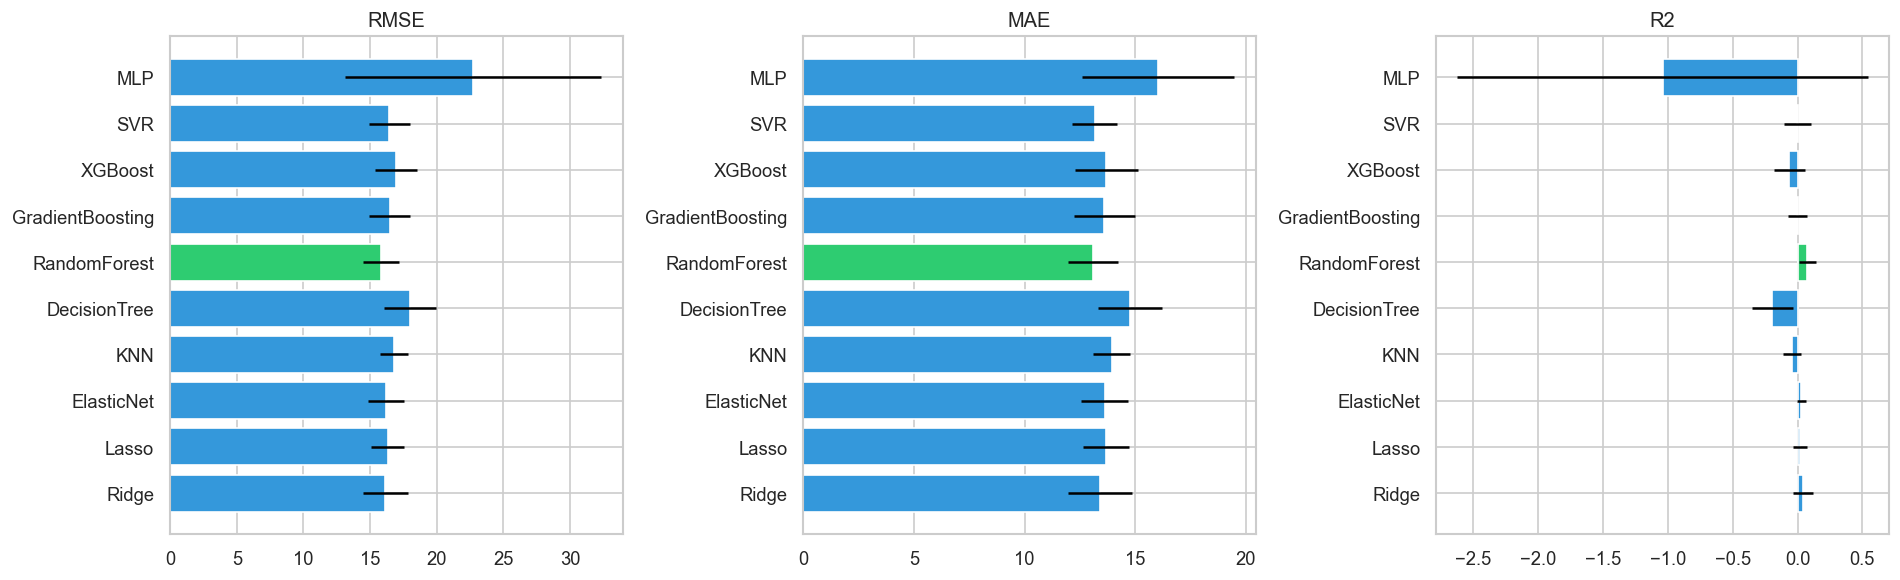


Campeon Nested CV: RandomForest (R2=0.074~0.066)


In [25]:
cols = ['RMSE_mean', 'RMSE_std', 'MAE_mean', 'MAE_std', 'R2_mean', 'R2_std', 'tiempo_mean']
display(df_bench[cols].round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, met in enumerate(['RMSE_mean', 'MAE_mean', 'R2_mean']):
    err = met.replace('_mean', '_std')
    best = df_bench[met].min() if 'R2' not in met else df_bench[met].max()
    colors = ['#2ecc71' if v == best else '#3498db' for v in df_bench[met]]
    axes[i].barh(range(len(df_bench)), df_bench[met], xerr=df_bench[err], color=colors, edgecolor='white')
    axes[i].set_yticks(range(len(df_bench))); axes[i].set_yticklabels(df_bench.index)
    axes[i].set_title(met.replace('_mean', ''))
plt.tight_layout(); plt.savefig(RESULTADOS / 'benchmark_comparativo.png', dpi=100, bbox_inches='tight'); plt.show()
mejor_cv = df_bench['R2_mean'].idxmax()
print(f'\nCampeon Nested CV: {mejor_cv} (R2={df_bench.loc[mejor_cv, "R2_mean"]:.3f}~{df_bench.loc[mejor_cv, "R2_std"]:.3f})')

---
## 4. Paired t-test (Top 4)

In [26]:
top4 = df_bench.nlargest(4, 'R2_mean').index.tolist()
print(f'Top 4: {top4}\n')
for i in range(len(top4)):
    for j in range(i + 1, len(top4)):
        ri = detalles[top4[i]]['RMSE']; rj = detalles[top4[j]]['RMSE']
        t, p = ttest_rel(ri, rj)
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'n.s.'
        print(f'  {top4[i]:18s} vs {top4[j]:18s}: t={t:.3f}, p={p:.4f} {sig}')

Top 4: ['RandomForest', 'Ridge', 'ElasticNet', 'Lasso']

  RandomForest       vs Ridge             : t=-0.965, p=0.3893 n.s.
  RandomForest       vs ElasticNet        : t=-1.989, p=0.1177 n.s.
  RandomForest       vs Lasso             : t=-3.550, p=0.0238 **
  Ridge              vs ElasticNet        : t=-0.360, p=0.7372 n.s.
  Ridge              vs Lasso             : t=-0.563, p=0.6036 n.s.
  ElasticNet         vs Lasso             : t=-0.449, p=0.6770 n.s.


---
## 5. Optimizacion Extendida (HalvingSearch) + Hold-out

In [27]:
mejor_idx = df_bench['R2_mean'].idxmax()mejor_def = MODELOS[mejor_idx]pipe = Pipeline([('scaler', StandardScaler()), ('m', mejor_def['m'])])halving = HalvingRandomSearchCV(pipe, mejor_def['p'], cv=5, n_candidates=30, factor=2,    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1, verbose=0)halving.fit(X_train, y_train)print(f'Mejores params ({mejor_idx}):')for k, v in halving.best_params_.items(): print(f'  {k}: {v}')y_pred = halving.predict(X_test)print(f'\nHold-out: RMSE={np.sqrt(mean_squared_error(y_test, y_pred)):.2f}  MAE={mean_absolute_error(y_test, y_pred):.2f}  R2={r2_score(y_test, y_pred):.3f}')joblib.dump(halving.best_estimator_, RESULTADOS / 'modelo_campeon_halving.pkl')print('Modelo guardado en resultados/modelo_campeon_halving.pkl')

Mejores params (RandomForest):
  m__max_depth: 23
  m__max_features: None
  m__min_samples_leaf: 8
  m__min_samples_split: 5
  m__n_estimators: 509

Hold-out: RMSE=20.18  MAE=15.50  R2=0.021
Modelo guardado en resultados/modelo_campeon_halving.pkl


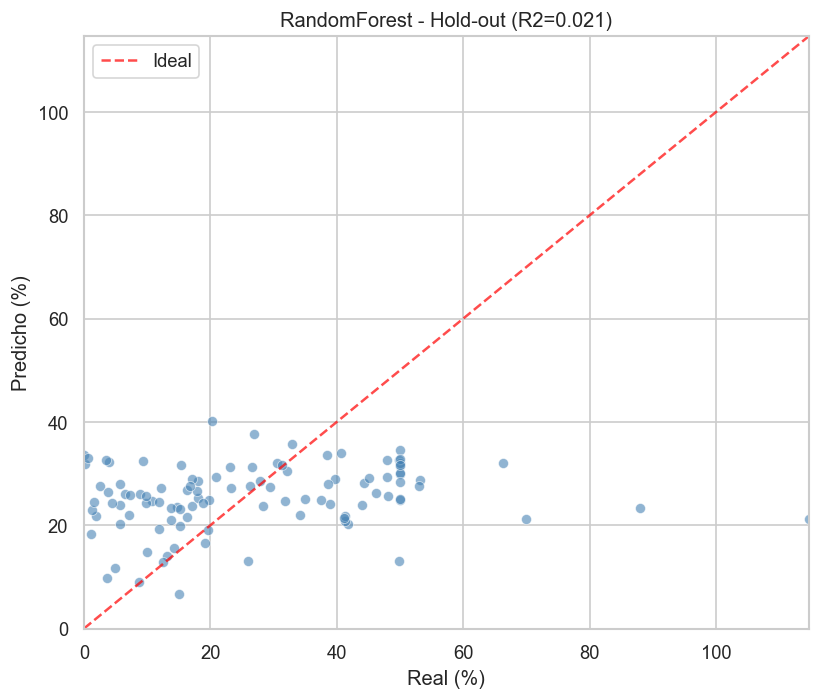

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='white', linewidth=0.5, c='steelblue')lims = [0, max(y_test.max(), y_pred.max())]ax.plot(lims, lims, 'r--', alpha=0.7, label='Ideal')ax.set_xlim(lims); ax.set_ylim(lims)ax.set_xlabel('Real (%)'); ax.set_ylabel('Predicho (%)')ax.set_title(f'{mejor_idx} - Halving (R2={r2_score(y_test, y_pred):.3f})')ax.legend(); plt.tight_layout()plt.savefig(RESULTADOS / 'holdout_scatter.png', dpi=100, bbox_inches='tight'); plt.show()

---
## 6. Optimizacion Bayesiana con Optuna

In [30]:
import optuna
from optuna.distributions import FloatDistribution
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, model_name, X, y):
    pipe = Pipeline([('scaler', StandardScaler()), ('m', mejor_def['m'].__class__(random_state=42))])
    params = {}
    for full_key, dist in mejor_def['p'].items():
        sk = full_key.replace('m__', '')
        
        # SOLUCIÓN: Detectar correctamente el tipo de distribución
        if hasattr(dist, 'rvs'):  # Distribuciones de scipy
            # Verificar si es loguniform (tiene parámetros y es una distribución)
            if hasattr(dist, 'a') and hasattr(dist, 'b'):
                # Para distribuciones uniformes, verificar si es logarítmica
                # Una forma simple es ver si el rango es muy amplio o hay un nombre específico
                if hasattr(dist, 'name') and 'log' in dist.name.lower():
                    params[sk] = trial.suggest_float(sk, dist.a, dist.b, log=True)
                else:
                    params[sk] = trial.suggest_float(sk, dist.a, dist.b)
            else:
                # Fallback para otras distribuciones scipy
                params[sk] = trial.suggest_float(sk, dist.ppf(0.05), dist.ppf(0.95))
        elif isinstance(dist, list):
            params[sk] = trial.suggest_categorical(sk, dist)
        elif isinstance(dist, (tuple, set)):
            params[sk] = trial.suggest_categorical(sk, list(dist))
        elif hasattr(dist, 'ppf'):
            lo = max(int(dist.ppf(0.05)), 1)
            hi = int(dist.ppf(0.95))
            params[sk] = trial.suggest_int(sk, lo, hi)
        elif hasattr(dist, 'a') and hasattr(dist, 'b'):
            # Distribución uniforme simple con atributos a y b
            params[sk] = trial.suggest_float(sk, dist.a, dist.b)
        else:
            # Último recurso: convertir a categorías
            try:
                params[sk] = trial.suggest_categorical(sk, list(dist))
            except:
                params[sk] = trial.suggest_categorical(sk, [float(dist)])
    
    pipe.set_params(**{'m__' + k: v for k, v in params.items()})
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr, vl in cv.split(X):
        X_tr, X_vl = X.iloc[tr], X.iloc[vl]
        y_tr, y_vl = y.iloc[tr], y.iloc[vl]
        pipe.fit(X_tr, y_tr)
        scores.append(rmse(y_vl, pipe.predict(X_vl)))
    return np.mean(scores)

---
## 7. Seleccion Multiobjetivo (Precision-Robustez-Complejidad-Interpretabilidad)

In [31]:
from sklearn.tree import DecisionTreeRegressor

proxy_complejidad = {
    'Ridge': 2, 'Lasso': 2, 'ElasticNet': 2,
    'KNN': 1, 'DecisionTree': 2,
    'RandomForest': 3, 'GradientBoosting': 3, 'XGBoost': 3,
    'SVR': 2, 'MLP': 3
}
proxy_interpretabilidad = {
    'Ridge': 5, 'Lasso': 5, 'ElasticNet': 4,
    'KNN': 4, 'DecisionTree': 5,
    'RandomForest': 4, 'GradientBoosting': 3, 'XGBoost': 3,
    'SVR': 2, 'MLP': 1
}

df_seleccion = df_bench[['R2_mean', 'RMSE_std', 'tiempo_mean']].copy()
df_seleccion['complejidad'] = [proxy_complejidad[m] for m in df_seleccion.index]
df_seleccion['interpretabilidad'] = [proxy_interpretabilidad[m] for m in df_seleccion.index]
df_seleccion['score_balance'] = (
    df_seleccion['R2_mean'] * 0.4
    - df_seleccion['RMSE_std'] * 0.0005
    - df_seleccion['tiempo_mean'] * 0.001
    - df_seleccion['complejidad'] * 0.05
    + df_seleccion['interpretabilidad'] * 0.05
)
print('=== SELECCION MULTIOBJETIVO ===')
print(f'{"Modelo":20s} {"R2":>6s} {"R2_std":>6s} {"T(s)":>6s} {"Comp":>4s} {"Interp":>4s} {"Score":>7s}')
print('-' * 60)
for idx, r in df_seleccion.sort_values('score_balance', ascending=False).iterrows():
    print(f'{idx:20s} {r["R2_mean"]:5.3f}  {r["RMSE_std"]:5.2f} {r["tiempo_mean"]:5.0f}  {int(r["complejidad"]):4d} {int(r["interpretabilidad"]):5d} {r["score_balance"]:6.3f}')

print(f'\nCampeon por R2 puro: {df_bench["R2_mean"].idxmax()}')
top_balance = df_seleccion['score_balance'].idxmax()
print(f'Campeon multiobjetivo: {top_balance} (score={df_seleccion.loc[top_balance, "score_balance"]:.3f})')
print(f'\nConclusion: {"Coinciden ambos criterios" if top_balance == df_bench["R2_mean"].idxmax() else "El multiobjetivo favorece a " + top_balance + " por mejor balance precision-robustez-complejidad-interpretabilidad"}')

=== SELECCION MULTIOBJETIVO ===
Modelo                   R2 R2_std   T(s) Comp Interp   Score
------------------------------------------------------------
Ridge                0.040   1.69     2     2     5  0.164
Lasso                0.018   1.27     1     2     5  0.155
KNN                  -0.043   1.07     1     1     4  0.131
ElasticNet           0.030   1.36     1     2     4  0.110
DecisionTree         -0.195   1.94     1     2     5  0.070
RandomForest         0.074   1.36    34     3     4  0.045
SVR                  -0.000   1.56     1     2     2 -0.002
XGBoost              -0.063   1.60    19     3     3 -0.045
GradientBoosting     -0.001   1.54    64     3     3 -0.065
MLP                  -1.041   9.60     9     3     1 -0.530

Campeon por R2 puro: RandomForest
Campeon multiobjetivo: Ridge (score=0.164)

Conclusion: El multiobjetivo favorece a Ridge por mejor balance precision-robustez-complejidad-interpretabilidad


---
## 8. Learning Curve

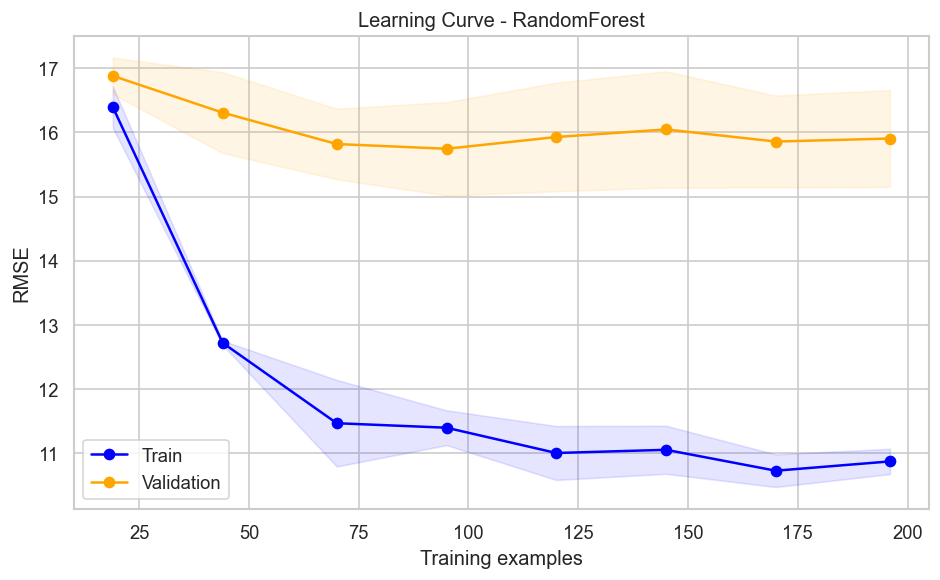

In [32]:
train_sizes = np.linspace(0.1, 1.0, 8)
lc = learning_curve(halving.best_estimator_, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error', train_sizes=train_sizes, n_jobs=-1)
ts = lc[0]; train_mean = -lc[1].mean(axis=1); train_std = lc[1].std(axis=1)
test_mean = -lc[2].mean(axis=1); test_std = lc[2].std(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(ts, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax.fill_between(ts, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
ax.plot(ts, train_mean, 'o-', label='Train', color='blue')
ax.plot(ts, test_mean, 'o-', label='Validation', color='orange')
ax.set_xlabel('Training examples'); ax.set_ylabel('RMSE')
ax.set_title(f'Learning Curve - {mejor_idx}'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTADOS / 'learning_curve.png', dpi=100, bbox_inches='tight'); plt.show()

---
## 9. Residual Analysis

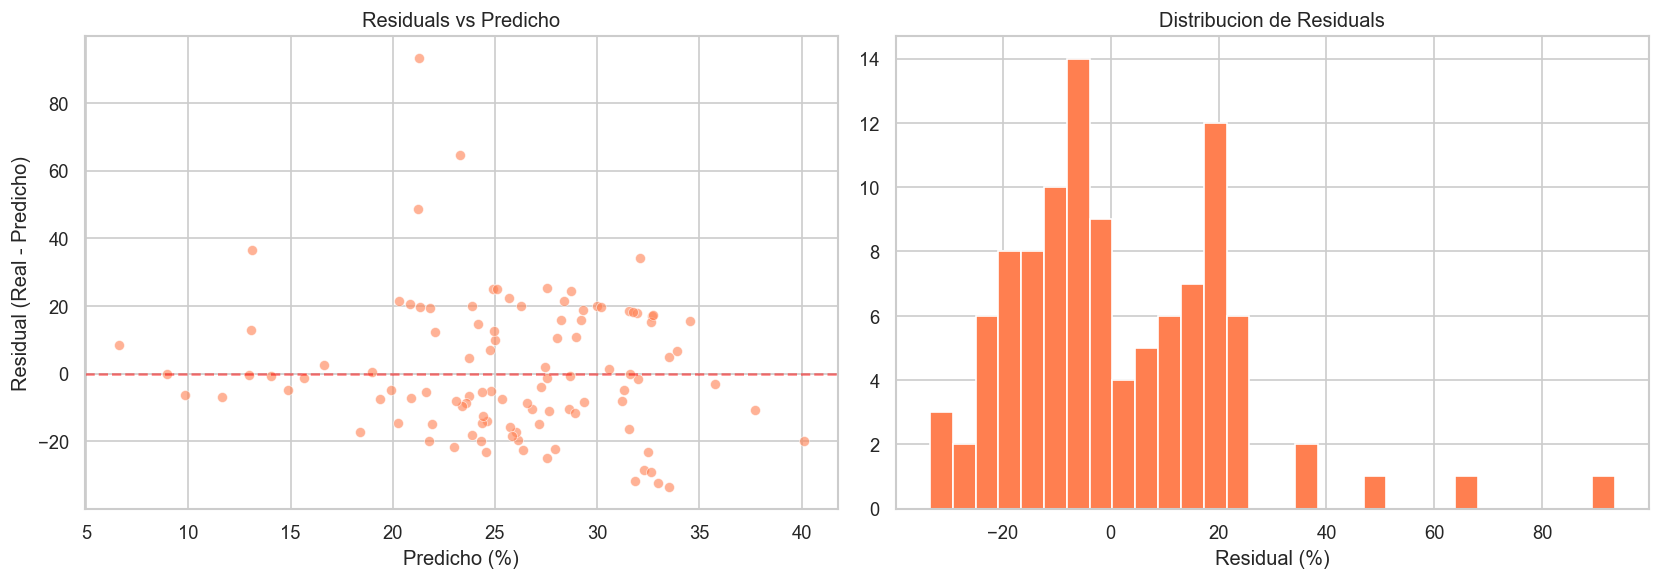

Residuals: mean=1.2%, std=20.2%


In [33]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, residuals, alpha=0.6, edgecolors='white', linewidth=0.5, c='coral')
axes[0].axhline(0, color='red', ls='--', alpha=0.5)
axes[0].set_xlabel('Predicho (%)'); axes[0].set_ylabel('Residual (Real - Predicho)')
axes[0].set_title('Residuals vs Predicho')
axes[1].hist(residuals, bins=30, edgecolor='white', color='coral')
axes[1].set_xlabel('Residual (%)'); axes[1].set_title('Distribucion de Residuals')
plt.tight_layout(); plt.savefig(RESULTADOS / 'residuals.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'Residuals: mean={residuals.mean():.1f}%, std={residuals.std():.1f}%')

---
## 10. SHAP / Permutation Importance

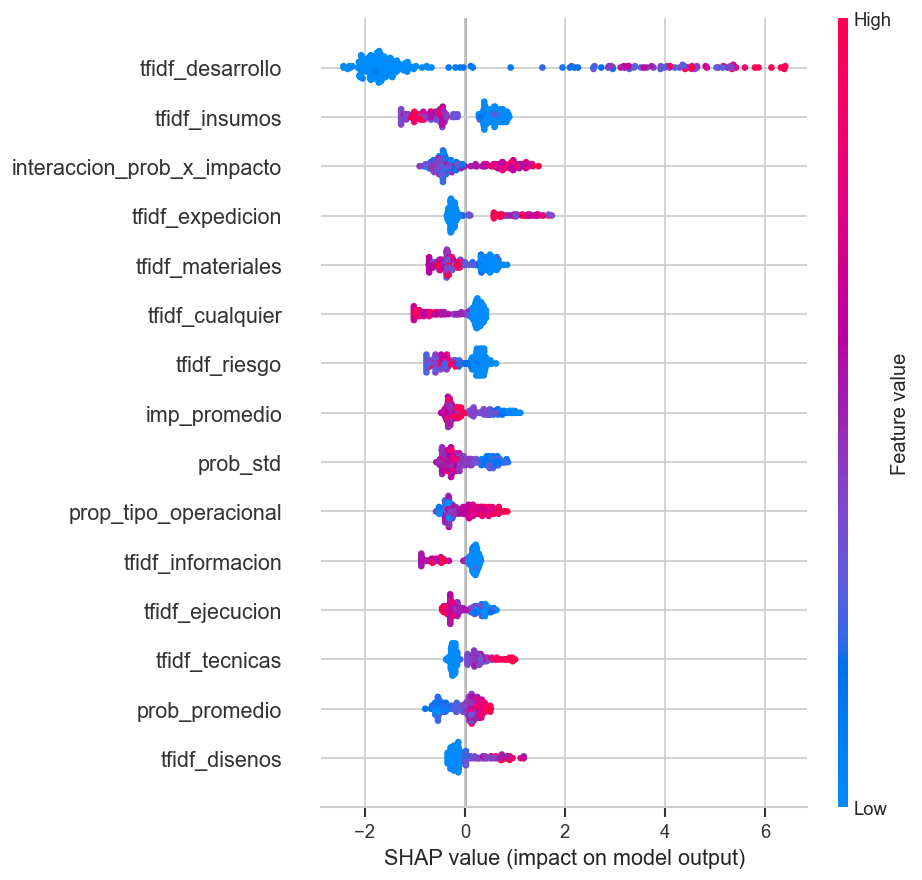

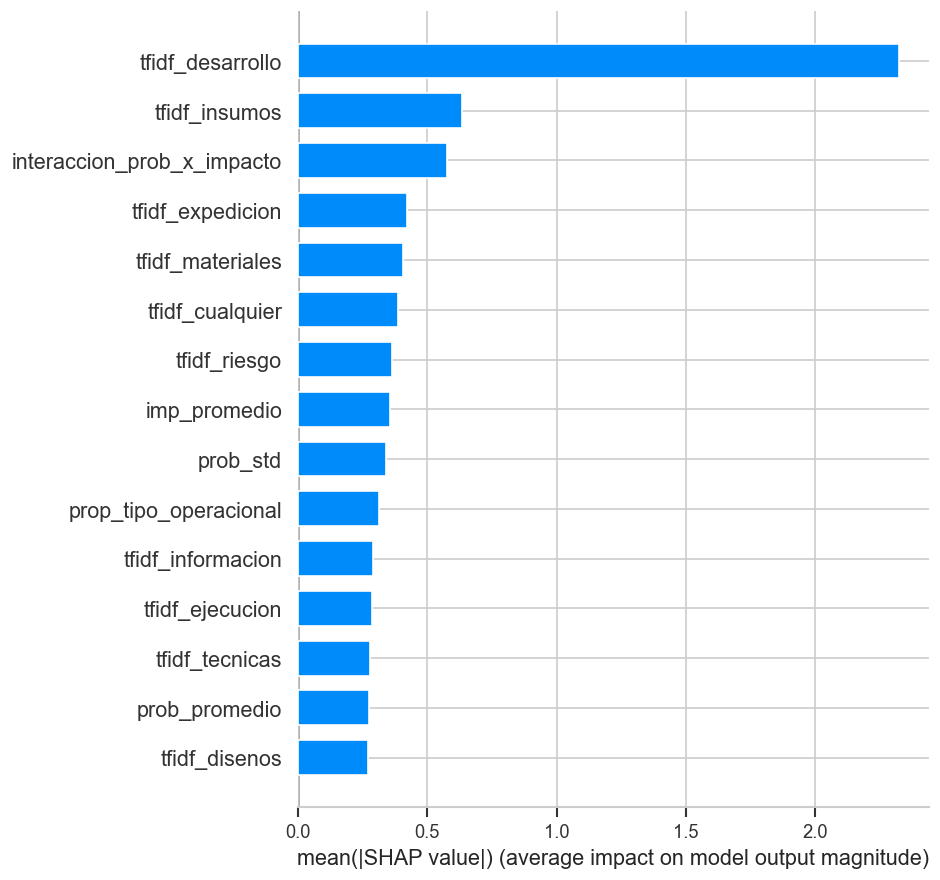

SHAP plots generados


In [34]:
try:
    import shap
    modelo_interno = halving.best_estimator_.named_steps['m']
    X_s = halving.best_estimator_.named_steps['scaler'].transform(X_train)
    if mejor_idx in ('RandomForest', 'XGBoost', 'GradientBoosting'):
        explainer = shap.TreeExplainer(modelo_interno)
        shap_values = explainer.shap_values(X_s)
        fig, ax = plt.subplots(figsize=(10, 8))
        shap.summary_plot(shap_values, X_s, feature_names=list(X_train.columns), show=False, max_display=15)
        plt.tight_layout(); plt.savefig(RESULTADOS / 'shap_summary.png', dpi=100, bbox_inches='tight'); plt.show()
        fig, ax = plt.subplots(figsize=(10, 6))
        shap.summary_plot(shap_values, X_s, feature_names=list(X_train.columns), plot_type='bar', show=False, max_display=15)
        plt.tight_layout(); plt.savefig(RESULTADOS / 'shap_importance.png', dpi=100, bbox_inches='tight'); plt.show()
        print('SHAP plots generados')
    else:
        from sklearn.inspection import permutation_importance
        perm = permutation_importance(halving.best_estimator_, X_test, y_test, n_repeats=15, random_state=42)
        imp = pd.DataFrame({'feature': X_train.columns, 'importance': perm.importances_mean}).sort_values('importance', ascending=True).tail(15)
        imp.plot.barh(x='feature', y='importance', figsize=(10, 6), legend=False, color='steelblue')
        plt.title('Permutation Importance'); plt.tight_layout()
        plt.savefig(RESULTADOS / 'permutation_importance.png', dpi=100, bbox_inches='tight'); plt.show()
except Exception as e:
    print(f'SHAP error: {e}')
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(halving.best_estimator_, X_test, y_test, n_repeats=15, random_state=42)
    imp = pd.DataFrame({'feature': X_train.columns, 'importance': perm.importances_mean}).sort_values('importance', ascending=True).tail(15)
    imp.plot.barh(x='feature', y='importance', figsize=(10, 6), legend=False, color='steelblue')
    plt.title('Permutation Importance'); plt.tight_layout()
    plt.savefig(RESULTADOS / 'permutation_importance.png', dpi=100, bbox_inches='tight'); plt.show()

---
## 11. Conclusiones

In [37]:
print('=' * 60)
print('  RESUMEN FINAL DEL BENCHMARKING')
print('=' * 60)
print(f'\nDataset: {len(y_sin)} contratos (>200 eliminados: {outliers_mask.sum()})')
print(f'Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(feature_cols)}')
print(f'\nNested CV (5x5, 100 iter por modelo):')
display(df_bench[cols].sort_values('R2_mean', ascending=False).round(3))
print(f'\nModelo campeon R2: {mejor_idx}')
r2_cv = df_bench.loc[mejor_idx, 'R2_mean']
r2_cv_std = df_bench.loc[mejor_idx, 'R2_std']
rmse_cv = df_bench.loc[mejor_idx, 'RMSE_mean']
rmse_cv_std = df_bench.loc[mejor_idx, 'RMSE_std']
print(f'  R2  Nested CV: {r2_cv:.3f} +- {r2_cv_std:.3f}')
print(f'  RMSE Nested CV: {rmse_cv:.1f} +- {rmse_cv_std:.1f}')
print(f'  R2  Hold-out (Halving): {r2_score(y_test, y_pred):.3f}')
print(f'  RMSE Hold-out (Halving): {np.sqrt(mean_squared_error(y_test, y_pred)):.1f}')
print(f'  MAE  Hold-out (Halving): {mean_absolute_error(y_test, y_pred):.1f}')
print(f'\nSeleccion Multiobjetivo:')
print(f'  Campeon balanceado: {top_balance}')
print(f'\nProximos pasos:')
print('  1. Refinar features (interacciones, mas texto)')
print('  2. Probar con target log-transformado')
print('  3. Validacion externa con contratos fuera de muestra')
print('  4. Prototipo Streamlit')

  RESUMEN FINAL DEL BENCHMARKING

Dataset: 350 contratos (>200 eliminados: 1)
Train: 245 | Test: 105 | Features: 215

Nested CV (5x5, 100 iter por modelo):


,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,tiempo_mean
modelo,,,,,,,
RandomForest,15.839,1.359,13.100,1.137,0.074,0.066,33.524
Ridge,16.144,1.686,13.404,1.452,0.040,0.076,1.622
ElasticNet,16.220,1.360,13.611,1.081,0.030,0.037,1.109
Lasso,16.307,1.268,13.673,1.030,0.018,0.053,1.228
SVR,16.451,1.563,13.174,1.020,-0.000,0.106,1.242
GradientBoosting,16.476,1.536,13.590,1.377,-0.001,0.072,63.657
KNN,16.790,1.072,13.934,0.832,-0.043,0.066,1.022
XGBoost,16.954,1.600,13.694,1.410,-0.063,0.121,19.403
DecisionTree,17.977,1.942,14.747,1.448,-0.195,0.158,0.992



Modelo campeon R2: RandomForest
  R2  Nested CV: 0.074 +- 0.066
  RMSE Nested CV: 15.8 +- 1.4
  R2  Hold-out (Halving): 0.021
  RMSE Hold-out (Halving): 20.2
  MAE  Hold-out (Halving): 15.5

Seleccion Multiobjetivo:
  Campeon balanceado: Ridge

Proximos pasos:
  1. Refinar features (interacciones, mas texto)
  2. Probar con target log-transformado
  3. Validacion externa con contratos fuera de muestra
  4. Prototipo Streamlit
